# 조기이탈 / 중도이탈 예측 모델 (Train 학습 → Test 검증)
- **조기이탈 모델**: `[산학과제]1016_예측모델_생성.ipynb`의 조기제적 모델 기반, 타겟 `조기_제적여부`, 전체 학생 대상
- **중도이탈 모델**: `[산학]최종중도모델+추가분석.ipynb` 기반, 타겟 `중도_제적여부`, **조기제적자(`조기_제적여부==1`) 제외** 후 학습 (원본과 동일)
  - 판정: **위험군**(원본의 고위험+중위험) / **저위험군** 2단계
- 두 모델은 서로의 예측값/라벨을 입력으로 쓰지 않는 독립 모델입니다. (데이터상 두 라벨은 동시에 1인 경우가 없음)
- 학습: `SW_Train_noised_제적라벨.xlsx` 80/20 층화분할 (Train / Validation)
- 검증: 같은 모델로 `SW_Test_noised_제적라벨.xlsx` 평가. 임계값은 Validation에서 정하고 Test에는 그대로 적용

In [1]:
# ==============================
# 0. 설정
# ==============================
# 폴더 구조: DATA/raw (입력), DATA/output (결과 표), DATA/figures (그림)
import os
DATA_DIR = "../DATA"
OUT_DIR = f"{DATA_DIR}/output"
FIG_DIR = f"{DATA_DIR}/figures"
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

TRAIN_PATH = f"{DATA_DIR}/raw/SW_Train_noised_제적라벨.xlsx"
TEST_PATH  = f"{DATA_DIR}/raw/SW_Test_noised_제적라벨.xlsx"
RANDOM_STATE = 42

EARLY_TARGET = "조기_제적여부"
MID_TARGET   = "중도_제적여부"

# 튜닝된 CatBoost 파라미터 (Validation AUC / 과적합 격차 기준으로 선택)
EARLY_PARAMS = {'iterations': 800, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}
MID_PARAMS   = {'iterations': 400, 'learning_rate': 0.03, 'depth': 3, 'l2_leaf_reg': 10}

# 임계값 선정 기준: Validation에서 Recall >= 0.8 을 만족하는 가장 높은 임계값
TARGET_RECALL = 0.8   # 조기이탈 모델 임계값 기준

# 중도이탈 모델: 위험군 / 저위험군 2단계 분류
#   - 위험군 기준 = Validation에서 Recall >= TARGET_RECALL 을 만족하는 가장 높은 임계값 (MID_LOW_THR)
#   - F1 최대 임계값(MID_HIGH_THR)은 위험군 내 우선순위 참고용
# 클래스 가중치는 불균형비의 제곱근으로 완화 (완전 균형 가중치는 확률을 과도하게 부풀림)
MID_CLASS_WEIGHT = "sqrt"

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import shap
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
from catboost import CatBoostClassifier, Pool

_installed = {f.name for f in fm.fontManager.ttflist}
FONT_NAME = next((f for f in ["Malgun Gothic", "NanumGothic", "AppleGothic"] if f in _installed), None)
if FONT_NAME:
    mpl.rcParams["font.family"] = FONT_NAME
mpl.rcParams["axes.unicode_minus"] = False
print("font:", FONT_NAME)

font: Malgun Gothic


## 1. 데이터 로드 및 파생변수

In [3]:
SEM = ['평점_1_1','평점_1_2','평점_2_1','평점_2_2','평점_3_1','평점_3_2','평점_4_1','평점_4_2']
CSAT = ['수능_등급_국어','수능_등급_수학','수능_등급_영어','수능_등급_탐구1','수능_등급_탐구2']
OVER = [f"{i}학년_초과학기_빈도" for i in range(1, 5)]

def build_features(df):
    df = df.copy()
    # P-only 플래그 + 숫자 변환 (원본 코드와 동일)
    for c in ["평점_1_1", "전체_평점", "직전학기_평점"]:
        df[f"{c}_Ponly"] = (df[c].astype(str) == "P").astype(int)
        df[c] = pd.to_numeric(df[c], errors="coerce")
    sem = df[SEM].apply(pd.to_numeric, errors="coerce")
    # 성적변화량 = 마지막 유효 학기 평점 - 첫 유효 학기 평점 (1016 노트북 방식)
    df["성적변화량"] = sem.ffill(axis=1).iloc[:, -1] - sem.bfill(axis=1).iloc[:, 0]
    # 최근_성적_증감 / 최근_성적경고_상태 (최종중도모델 노트북 방식)
    def recent(r):
        g = r.dropna().values
        d = g[-1] - g[-2] if len(g) >= 2 else 0.0
        l = g[-1] if len(g) else np.nan
        w = 0 if np.isnan(l) else (2 if l < 1.75 else (1 if l < 2.5 else 0))
        return pd.Series({"최근_성적_증감": d, "최근_성적경고_상태": w})
    df = pd.concat([df, sem.apply(recent, axis=1)], axis=1)
    df["최근_성적경고_상태"] = df["최근_성적경고_상태"].astype(int)
    df["초과학기_여부"] = (df[OVER] >= 1).any(axis=1).astype(int)
    df["수능_가중등급"] = df[CSAT].mean(axis=1)
    # 중도이탈용 성적 이력 파생변수
    df["최저평점"] = sem.min(axis=1)                 # 학기 평점 중 최저값
    df["저성적_학기수"] = (sem < 2.0).sum(axis=1)     # 평점 2.0 미만 학기 수
    return df

import os

def load_excel_cached(path):
    """엑셀을 한 번 읽어 같은 이름의 .pkl로 캐시합니다.
    (이 PC에서는 openpyxl의 XML 파서가 간헐적으로 비정상 종료되어, 두 번째 실행부터는 캐시를 사용)
    엑셀 파일이 캐시보다 새로우면 다시 읽습니다."""
    pkl = os.path.splitext(path)[0] + ".pkl"
    if os.path.exists(pkl) and os.path.getmtime(pkl) >= os.path.getmtime(path):
        return pd.read_pickle(pkl)
    df = pd.read_excel(path)
    df.to_pickle(pkl)
    return df

train_raw = load_excel_cached(TRAIN_PATH)
test_raw  = load_excel_cached(TEST_PATH)
train_df = build_features(train_raw)
test_df  = build_features(test_raw)
print("train:", train_df.shape, " test:", test_df.shape)
for name, d in [("Train", train_df), ("Test", test_df)]:
    print(f"\n[{name}]")
    display(pd.crosstab(d[EARLY_TARGET], d[MID_TARGET], rownames=["조기"], colnames=["중도"]))

train: (10687, 70)  test: (2673, 70)

[Train]


중도,0,1
조기,,
0,8799,506
1,1382,0



[Test]


중도,0,1
조기,,
0,2220,125
1,328,0


### 변수 정의
원본 변수명 → 현재 데이터: `응시횟수_구분`→`응시구분`, `모집전형_세부`→`모집전형`+`지원자_세부유형`, `재학_대비_휴학비`→`휴학비율`.
현재 데이터에 없는 `1학년_비교과_참여횟수`(조기), `최근_비교과_참여증감`(중도)은 제외했습니다.
`현재_학적상태`, `제적_여부`는 타겟 누수이며 Test에는 비어 있으므로 사용하지 않습니다.

In [4]:
EARLY_CAT = ['성별','응시구분','학과명','추가합격_여부','모집전형','지원자_세부유형',
             '고교유형','고교지역A','고교지역B','일반휴학_여부']
EARLY_NUM = ['평균_소득분위','평점_1_1','수능_가중등급','휴학비율','평점_1_1_Ponly']

MID_CAT = ['성별','응시구분','학과명','추가합격_여부','모집전형','지원자_세부유형','초과학기_여부',
           '고교유형','고교지역B','일반휴학_여부','전과_여부','다전공_이수_여부','교환학생_여부',
           '학점교류_여부','최근_성적경고_상태']
MID_NUM = ['소득분위_변화','평균_소득분위','전체_평점','직전학기_평점','성적경고_횟수','성적_분산','성적변화량',
           '비교과_참여횟수','수능_가중등급','휴학비율','최근_성적_증감','전체_평점_Ponly','직전학기_평점_Ponly',
           # 추가: 성적/학적 이력
           '성적변화량_분산','최저평점','저성적_학기수','휴학학기','소속변경_여부']

def make_X(df, cat, num):
    X = df[cat + num].copy()
    for c in cat:
        X[c] = X[c].astype(str)
    return X

## 2. 공통 함수 (학습 / 평가 / 시각화)

In [5]:
def fit_model(df, target, cat, num, params, name, cw_mode="balanced"):
    X = make_X(df, cat, num)
    y = df[target].astype(int)
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    ratio = y_tr.value_counts()[0] / y_tr.value_counts()[1]
    cw = [1, np.sqrt(ratio)] if cw_mode == "sqrt" else [1, ratio]   # 클래스 불균형 보정
    model = CatBoostClassifier(cat_features=cat, class_weights=cw, random_state=RANDOM_STATE,
                               verbose=0, allow_writing_files=False, **params)
    model.fit(X_tr, y_tr)
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_va = model.predict_proba(X_va)[:, 1]
    print(f"[{name}] 학습 데이터 {len(X)}명 (양성 {y.sum()}명, {y.mean()*100:.1f}%)")
    print(f"[{name}] Train AUC = {roc_auc_score(y_tr, p_tr):.4f} | Validation AUC = {roc_auc_score(y_va, p_va):.4f}")
    return dict(model=model, cat=cat, num=num, X_tr=X_tr, X_va=X_va, y_tr=y_tr, y_va=y_va, p_tr=p_tr, p_va=p_va)

def pick_threshold(y, p, target_recall=TARGET_RECALL):
    prec, rec, thr = precision_recall_curve(y, p)
    idx = np.where(rec[:-1] >= target_recall)[0]
    return float(thr[idx[-1]]) if len(idx) else 0.5

def pick_threshold_f1(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return float(thr[int(np.argmax(f1[:-1]))])

def report(y, p, split, thr, label):
    pred = (p >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    print(f"\n===== {split} (threshold={thr:.3f}) =====")
    print(f"ROC-AUC: {roc_auc_score(y, p):.4f} | PR-AUC(AP): {average_precision_score(y, p):.4f} | Accuracy: {accuracy_score(y, pred):.4f}")
    display(pd.DataFrame(cm, index=["실제: 비이탈", f"실제: {label}"], columns=["예측: 비이탈", f"예측: {label}"]))
    print(classification_report(y, pred, target_names=["비이탈", label], digits=4))

def plot_roc(curves, title, fname):
    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=120)
    for (lab, y, p), ls in zip(curves, ["-", "--", "-."]):
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, lw=2, ls=ls, label=f"{lab} (AUC = {roc_auc_score(y, p):.3f})")
    ax.plot([0, 1], [0, 1], ls=":", lw=1, alpha=0.7, label="Chance")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    fig.tight_layout(); fig.savefig(fname, dpi=300, bbox_inches="tight"); plt.show()

def plot_shap(res, title):
    pool = Pool(res["X_va"], label=res["y_va"], cat_features=res["cat"])
    sv = res["model"].get_feature_importance(pool, type="ShapValues")[:, :-1]
    names = res["X_va"].columns.tolist()
    shap.summary_plot(sv, res["X_va"], show=False, max_display=20)
    plt.title(title); plt.tight_layout(); plt.show()
    imp = pd.DataFrame({"feature": names, "mean|SHAP|": np.abs(sv).mean(axis=0)}).sort_values("mean|SHAP|", ascending=False)
    display(imp.head(10).reset_index(drop=True))

## 3. 조기이탈 모델 (타겟: `조기_제적여부`, 전체 학생)

In [6]:
early = fit_model(train_df, EARLY_TARGET, EARLY_CAT, EARLY_NUM, EARLY_PARAMS, "조기이탈")
EARLY_THR = pick_threshold(early["y_va"], early["p_va"])
print(f"조기이탈 임계값 (Validation Recall≥{TARGET_RECALL}): {EARLY_THR:.3f}")
report(early["y_tr"], early["p_tr"], "조기이탈 - Train", EARLY_THR, "조기이탈")
report(early["y_va"], early["p_va"], "조기이탈 - Validation", EARLY_THR, "조기이탈")

[조기이탈] 학습 데이터 10687명 (양성 1382명, 12.9%)
[조기이탈] Train AUC = 0.9654 | Validation AUC = 0.9521
조기이탈 임계값 (Validation Recall≥0.8): 0.730

===== 조기이탈 - Train (threshold=0.730) =====
ROC-AUC: 0.9654 | PR-AUC(AP): 0.8447 | Accuracy: 0.9413


,예측: 비이탈,예측: 조기이탈
실제: 비이탈,7154,289
실제: 조기이탈,213,893


              precision    recall  f1-score   support

         비이탈     0.9711    0.9612    0.9661      7443
        조기이탈     0.7555    0.8074    0.7806      1106

    accuracy                         0.9413      8549
   macro avg     0.8633    0.8843    0.8733      8549
weighted avg     0.9432    0.9413    0.9421      8549


===== 조기이탈 - Validation (threshold=0.730) =====
ROC-AUC: 0.9521 | PR-AUC(AP): 0.8072 | Accuracy: 0.9420


,예측: 비이탈,예측: 조기이탈
실제: 비이탈,1793,69
실제: 조기이탈,55,221


              precision    recall  f1-score   support

         비이탈     0.9702    0.9629    0.9666      1862
        조기이탈     0.7621    0.8007    0.7809       276

    accuracy                         0.9420      2138
   macro avg     0.8662    0.8818    0.8737      2138
weighted avg     0.9434    0.9420    0.9426      2138



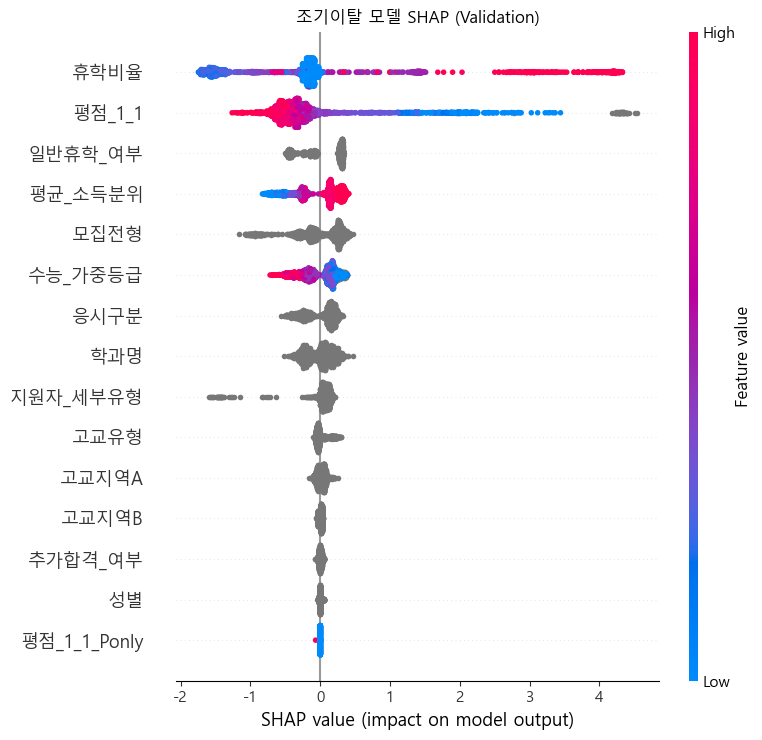

,feature,mean|SHAP|
0,휴학비율,0.923762
1,평점_1_1,0.634351
2,일반휴학_여부,0.291349
3,평균_소득분위,0.288707
4,모집전형,0.257460
5,수능_가중등급,0.214176
6,응시구분,0.194333
7,학과명,0.156488
8,지원자_세부유형,0.095888
9,고교유형,0.061612


In [7]:
plot_shap(early, "조기이탈 모델 SHAP (Validation)")

## 4. 중도이탈 모델 (타겟: `중도_제적여부`, 조기제적자 제외)
- 성적 이력 변수 5개 추가: `성적변화량_분산`, `최저평점`, `저성적_학기수`, `휴학학기`, `소속변경_여부`
- 클래스 가중치: 불균형비의 제곱근
- 판정: **위험군**(p ≥ `MID_LOW_THR`, Validation Recall 0.8 기준) / **저위험군**
- 참고: F1 최대 임계값(`MID_HIGH_THR`) 이상은 위험군 내 우선 상담 대상

In [8]:
mid_train_df = train_df[train_df[EARLY_TARGET] != 1].copy()
mid = fit_model(mid_train_df, MID_TARGET, MID_CAT, MID_NUM, MID_PARAMS, "중도이탈", cw_mode=MID_CLASS_WEIGHT)

# 판정 기준 (Validation에서 결정, Test에는 그대로 적용)
#  - 위험군  : p >= MID_LOW_THR  (Validation Recall >= TARGET_RECALL 을 확보하는 가장 높은 임계값)
#  - 저위험군: p <  MID_LOW_THR
#  - 참고   : p >= MID_HIGH_THR (F1 최대 임계값)은 위험군 내 우선 상담 대상
MID_HIGH_THR = pick_threshold_f1(mid["y_va"], mid["p_va"])
MID_LOW_THR = min(pick_threshold(mid["y_va"], mid["p_va"], TARGET_RECALL), MID_HIGH_THR)
MID_THR = MID_LOW_THR   # 중도이탈 판정 임계값 = 위험군 기준
print(f"위험군 기준 (Validation Recall≥{TARGET_RECALL}): {MID_LOW_THR:.3f} | 우선순위 참고 (F1 최대): {MID_HIGH_THR:.3f}")
report(mid["y_tr"], mid["p_tr"], "중도이탈 - Train (위험군 기준)", MID_THR, "중도이탈")
report(mid["y_va"], mid["p_va"], "중도이탈 - Validation (위험군 기준)", MID_THR, "중도이탈")

[중도이탈] 학습 데이터 9305명 (양성 506명, 5.4%)
[중도이탈] Train AUC = 0.9179 | Validation AUC = 0.8902
위험군 기준 (Validation Recall≥0.8): 0.161 | 우선순위 참고 (F1 최대): 0.388

===== 중도이탈 - Train (위험군 기준) (threshold=0.161) =====
ROC-AUC: 0.9179 | PR-AUC(AP): 0.5262 | Accuracy: 0.8040


,예측: 비이탈,예측: 중도이탈
실제: 비이탈,5635,1404
실제: 중도이탈,55,350


              precision    recall  f1-score   support

         비이탈     0.9903    0.8005    0.8854      7039
        중도이탈     0.1995    0.8642    0.3242       405

    accuracy                         0.8040      7444
   macro avg     0.5949    0.8324    0.6048      7444
weighted avg     0.9473    0.8040    0.8548      7444


===== 중도이탈 - Validation (위험군 기준) (threshold=0.161) =====
ROC-AUC: 0.8902 | PR-AUC(AP): 0.4970 | Accuracy: 0.8066


,예측: 비이탈,예측: 중도이탈
실제: 비이탈,1420,340
실제: 중도이탈,20,81


              precision    recall  f1-score   support

         비이탈     0.9861    0.8068    0.8875      1760
        중도이탈     0.1924    0.8020    0.3103       101

    accuracy                         0.8066      1861
   macro avg     0.5893    0.8044    0.5989      1861
weighted avg     0.9430    0.8066    0.8562      1861



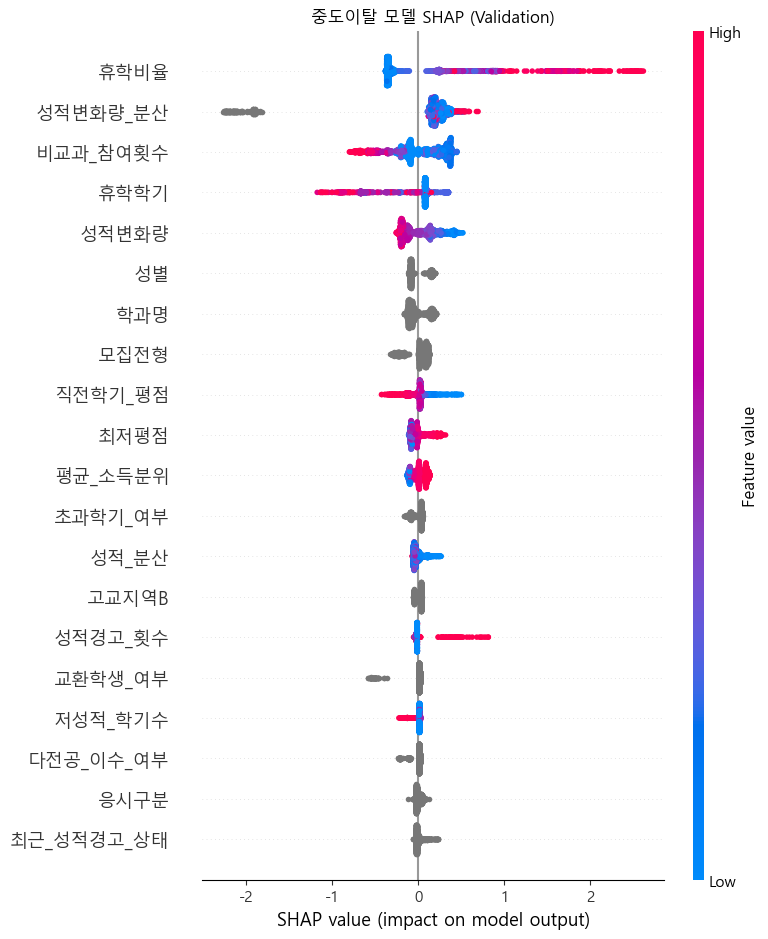

,feature,mean|SHAP|
0,휴학비율,0.510629
1,성적변화량_분산,0.420116
2,비교과_참여횟수,0.253067
3,휴학학기,0.228405
4,성적변화량,0.176780
5,성별,0.111379
6,학과명,0.098524
7,모집전형,0.094265
8,직전학기_평점,0.077562
9,최저평점,0.075364


In [9]:
plot_shap(mid, "중도이탈 모델 SHAP (Validation)")

## 5. Test 데이터 검증
Train에서 학습한 모델과 Validation에서 정한 임계값을 그대로 Test에 적용합니다.
- 조기이탈: Test 전체
- 중도이탈: Test 중 조기제적자 제외 (학습 조건과 동일)


===== 조기이탈 - Test (threshold=0.730) =====
ROC-AUC: 0.9471 | PR-AUC(AP): 0.8072 | Accuracy: 0.9420


,예측: 비이탈,예측: 조기이탈
실제: 비이탈,2256,89
실제: 조기이탈,66,262


              precision    recall  f1-score   support

         비이탈     0.9716    0.9620    0.9668      2345
        조기이탈     0.7464    0.7988    0.7717       328

    accuracy                         0.9420      2673
   macro avg     0.8590    0.8804    0.8693      2673
weighted avg     0.9439    0.9420    0.9429      2673



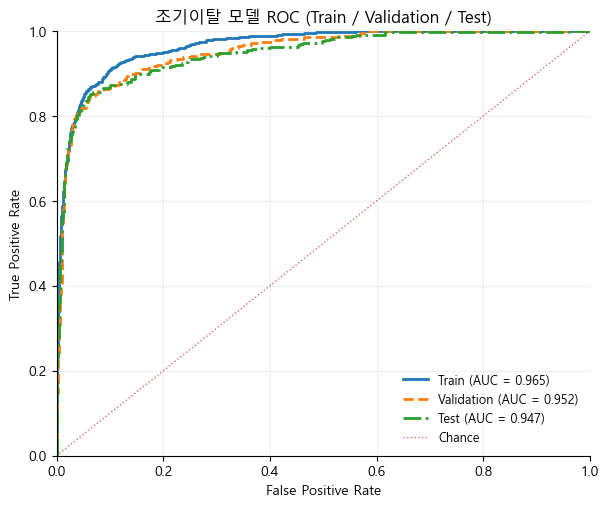

In [10]:
# --- 조기이탈 ---
X_te_early = make_X(test_df, EARLY_CAT, EARLY_NUM)
y_te_early = test_df[EARLY_TARGET].astype(int)
p_te_early = early["model"].predict_proba(X_te_early)[:, 1]
report(y_te_early, p_te_early, "조기이탈 - Test", EARLY_THR, "조기이탈")
plot_roc([("Train", early["y_tr"], early["p_tr"]), ("Validation", early["y_va"], early["p_va"]),
          ("Test", y_te_early, p_te_early)], "조기이탈 모델 ROC (Train / Validation / Test)", f"{FIG_DIR}/roc_early.png")


===== 중도이탈 - Test (위험군 기준) (threshold=0.161) =====
ROC-AUC: 0.9046 | PR-AUC(AP): 0.4610 | Accuracy: 0.8115


,예측: 비이탈,예측: 중도이탈
실제: 비이탈,1801,419
실제: 중도이탈,23,102


              precision    recall  f1-score   support

         비이탈     0.9874    0.8113    0.8907      2220
        중도이탈     0.1958    0.8160    0.3158       125

    accuracy                         0.8115      2345
   macro avg     0.5916    0.8136    0.6032      2345
weighted avg     0.9452    0.8115    0.8601      2345



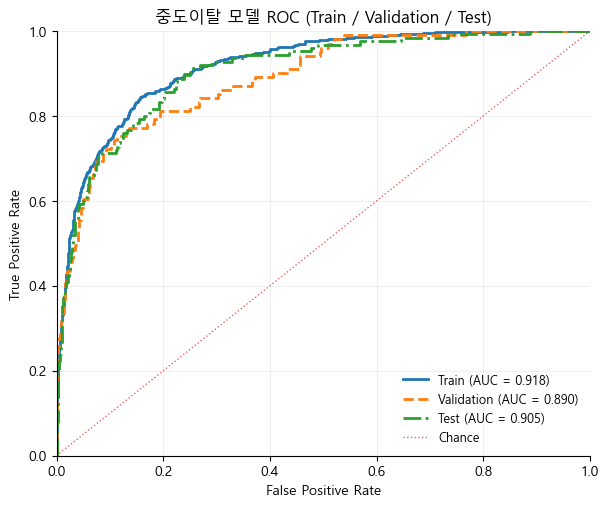

In [11]:
# --- 중도이탈 ---
mid_test_mask = test_df[EARLY_TARGET] != 1
X_te_mid = make_X(test_df.loc[mid_test_mask], MID_CAT, MID_NUM)
y_te_mid = test_df.loc[mid_test_mask, MID_TARGET].astype(int)
p_te_mid = mid["model"].predict_proba(X_te_mid)[:, 1]
report(y_te_mid, p_te_mid, "중도이탈 - Test (위험군 기준)", MID_THR, "중도이탈")
plot_roc([("Train", mid["y_tr"], mid["p_tr"]), ("Validation", mid["y_va"], mid["p_va"]),
          ("Test", y_te_mid, p_te_mid)], "중도이탈 모델 ROC (Train / Validation / Test)", f"{FIG_DIR}/roc_mid.png")

## 5-1. 중도이탈 2단계 위험군 (Train / Validation / Test)
고위험군과 중위험군을 **위험군** 하나로 합치고, 나머지를 **저위험군**으로 둡니다.
- **위험군** (p ≥ `MID_LOW_THR`): Validation에서 Recall ≥ 0.8을 확보하는 임계값 이상 → 상담 및 모니터링 대상
- **저위험군** (p < `MID_LOW_THR`): 일반 관리

임계값은 Validation에서 정하고 Test에는 그대로 적용합니다.
참고로 위험군 안에서 확률이 `MID_HIGH_THR`(F1 최대 임계값) 이상인 학생은 실제 이탈 비율이 훨씬 높으므로, 우선순위를 정할 때 활용할 수 있습니다.

In [12]:
RISK_ORDER = ["위험군", "저위험군"]

def assign_mid_risk(p):
    return np.where(np.asarray(p) >= MID_LOW_THR, "위험군", "저위험군")

def risk_table(y, p, split):
    g = pd.Series(assign_mid_risk(p), name="위험군")
    y = pd.Series(np.asarray(y), name="실제")
    t = pd.DataFrame({"학생 수": g.value_counts(), "실제 중도이탈": y.groupby(g).sum()}).reindex(RISK_ORDER).fillna(0).astype(int)
    t["군 내 이탈 비율(Precision)"] = t["실제 중도이탈"] / t["학생 수"].replace(0, np.nan)
    t["전체 이탈자 중 비중(Recall)"] = t["실제 중도이탈"] / y.sum()
    t["데이터"] = split
    return t

risk_all = pd.concat([risk_table(mid["y_tr"], mid["p_tr"], "Train"),
                      risk_table(mid["y_va"], mid["p_va"], "Validation"),
                      risk_table(y_te_mid, p_te_mid, "Test")])
print(f"위험군 ≥ {MID_LOW_THR:.3f} | 저위험군 < {MID_LOW_THR:.3f}")
display(risk_all.style.format({"군 내 이탈 비율(Precision)": "{:.3f}", "전체 이탈자 중 비중(Recall)": "{:.3f}",
                               "학생 수": "{:,.0f}", "실제 중도이탈": "{:,.0f}"}))
risk_all.to_excel(f"{OUT_DIR}/중도이탈_위험군_요약.xlsx")

# 참고: 위험군 중 우선 상담 대상 (p >= MID_HIGH_THR)
for split, yy, pp in [("Train", mid["y_tr"], mid["p_tr"]), ("Validation", mid["y_va"], mid["p_va"]), ("Test", y_te_mid, p_te_mid)]:
    yy, pp = np.asarray(yy), np.asarray(pp)
    m = pp >= MID_HIGH_THR
    print(f"[{split}] 우선 상담(≥{MID_HIGH_THR:.3f}) {m.sum()}명 중 실제 이탈 {yy[m].sum()}명 ({yy[m].mean():.1%})")

위험군 ≥ 0.161 | 저위험군 < 0.161


,학생 수,실제 중도이탈,군 내 이탈 비율(Precision),전체 이탈자 중 비중(Recall),데이터
위험군,,,,,
위험군,"1,754",350,0.200,0.864,Train
저위험군,"5,690",55,0.010,0.136,Train
위험군,421,81,0.192,0.802,Validation
저위험군,"1,440",20,0.014,0.198,Validation
위험군,521,102,0.196,0.816,Test
저위험군,"1,824",23,0.013,0.184,Test


[Train] 우선 상담(≥0.388) 560명 중 실제 이탈 251명 (44.8%)
[Validation] 우선 상담(≥0.388) 140명 중 실제 이탈 59명 (42.1%)
[Test] 우선 상담(≥0.388) 169명 중 실제 이탈 74명 (43.8%)


## 6. 성능 요약 및 Test 예측 결과 저장

In [13]:
def row(model_name, split, y, p, thr):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"모델": model_name, "데이터": split, "N": len(y), "양성": int(y.sum()),
            "ROC-AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p), "임계값": thr,
            "Recall": tp / (tp + fn) if tp + fn else np.nan, "Precision": tp / (tp + fp) if tp + fp else np.nan,
            "Accuracy": (tp + tn) / len(y)}

summary = pd.DataFrame([
    row("조기이탈", "Train", early["y_tr"], early["p_tr"], EARLY_THR),
    row("조기이탈", "Validation", early["y_va"], early["p_va"], EARLY_THR),
    row("조기이탈", "Test", y_te_early, p_te_early, EARLY_THR),
    row("중도이탈", "Train", mid["y_tr"], mid["p_tr"], MID_THR),
    row("중도이탈", "Validation", mid["y_va"], mid["p_va"], MID_THR),
    row("중도이탈", "Test", y_te_mid, p_te_mid, MID_THR),
])
display(summary.style.format({c: "{:.4f}" for c in ["ROC-AUC", "PR-AUC", "임계값", "Recall", "Precision", "Accuracy"]}).hide(axis="index"))

# Test 예측 결과: 두 모델 확률을 각각 저장 (중도이탈 확률은 전체 Test 학생에 대해 계산, 평가만 조기제적자 제외)
out = test_raw[["ID", EARLY_TARGET, MID_TARGET]].copy()
out["조기이탈_확률"] = p_te_early
out["조기이탈_예측"] = (p_te_early >= EARLY_THR).astype(int)
out["중도이탈_확률"] = mid["model"].predict_proba(make_X(test_df, MID_CAT, MID_NUM))[:, 1]
out["중도이탈_예측"] = (out["중도이탈_확률"] >= MID_THR).astype(int)   # 1 = 위험군
out["중도이탈_위험군"] = assign_mid_risk(out["중도이탈_확률"].values)
out.loc[out[EARLY_TARGET] == 1, "중도이탈_위험군"] = "평가제외(조기제적)"
out.to_excel(f"{OUT_DIR}/Test_조기_중도_예측결과.xlsx", index=False)
summary.to_excel(f"{OUT_DIR}/모델_성능요약.xlsx", index=False)
print("저장 완료: Test_조기_중도_예측결과.xlsx, 모델_성능요약.xlsx")

모델,데이터,N,양성,ROC-AUC,PR-AUC,임계값,Recall,Precision,Accuracy
조기이탈,Train,8549,1106,0.9654,0.8447,0.7303,0.8074,0.7555,0.9413
조기이탈,Validation,2138,276,0.9521,0.8072,0.7303,0.8007,0.7621,0.9420
조기이탈,Test,2673,328,0.9471,0.8072,0.7303,0.7988,0.7464,0.9420
중도이탈,Train,7444,405,0.9179,0.5262,0.1610,0.8642,0.1995,0.8040
중도이탈,Validation,1861,101,0.8902,0.4970,0.1610,0.8020,0.1924,0.8066
중도이탈,Test,2345,125,0.9046,0.4610,0.1610,0.8160,0.1958,0.8115


저장 완료: Test_조기_중도_예측결과.xlsx, 모델_성능요약.xlsx


## 7. 개별 SHAP 분석 (Test 데이터)
Test 학생 한 명 한 명에 대해 SHAP 값을 계산해, **어떤 변수가 예측에 얼마나 영향을 줬는지**와 **변수 값이 커지거나 작아질 때 위험이 어떻게 움직이는지**를 정리합니다.
- SHAP 값은 로그오즈 단위입니다. **양수 = 이탈 위험을 높임, 음수 = 낮춤**. 한 학생의 SHAP 합계 + 기준값 = 그 학생의 예측 로그오즈
- 조기이탈: Test 전체 / 중도이탈: Test 중 조기제적자 제외
- 결과 파일: `SHAP_분석결과.xlsx` (중요도, 방향성, 학생별 SHAP 값, 학생별 주요 요인), `shap_*.png`

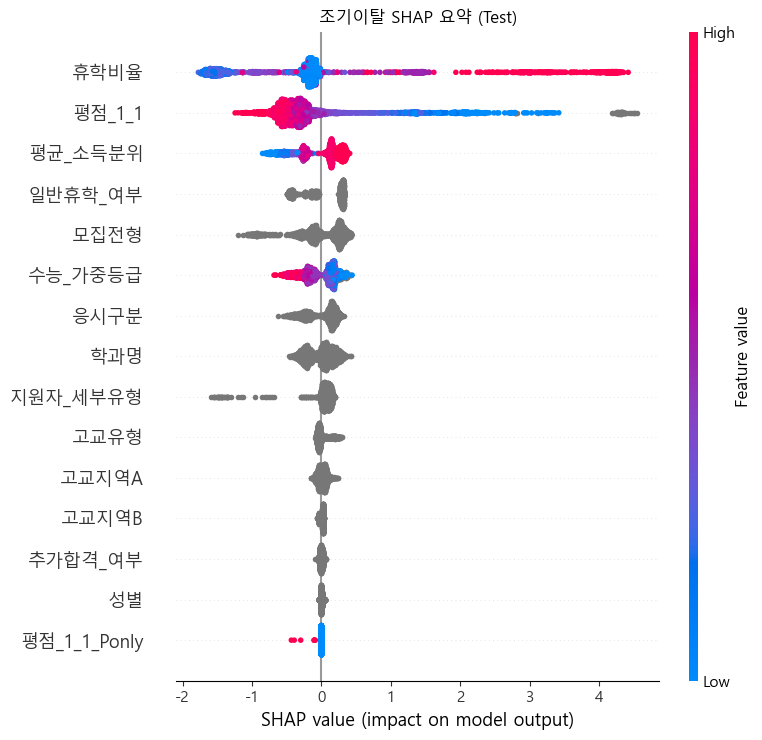

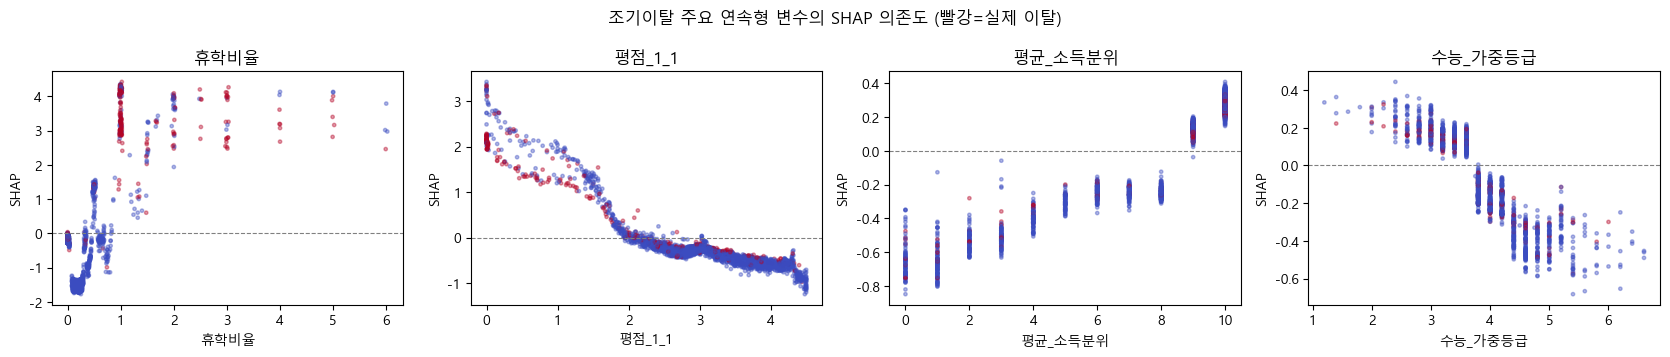


########## 조기이탈 ##########
[전역 중요도 Top 10]
 순위       변수  평균|SHAP|  비중(%)  누적비중(%)
  1     휴학비율     0.939 29.253   29.253
  2   평점_1_1     0.627 19.540   48.793
  3  평균_소득분위     0.290  9.038   57.831
  4  일반휴학_여부     0.289  9.001   66.831
  5     모집전형     0.255  7.929   74.760
  6  수능_가중등급     0.210  6.546   81.306
  7     응시구분     0.195  6.066   87.371
  8      학과명     0.158  4.938   92.309
  9 지원자_세부유형     0.094  2.943   95.252
 10     고교유형     0.058  1.812   97.064

[변수 방향성 Top 10]
 순위       변수  유형  Spearman(값↔SHAP)                                                     해석
  1     휴학비율 연속형              0.04      방향 약함/비선형 | 상위25%(≥0.30) +1.559, 하위25%(≤0) -0.142
  2   평점_1_1 연속형             -0.93  값이 클수록 위험↓ | 상위25%(≥3.72) -0.623, 하위25%(≤2.56) +0.748
  3  평균_소득분위 연속형              0.96       값이 클수록 위험↑ | 상위25%(≥10) +0.290, 하위25%(≤6) -0.466
  4  일반휴학_여부 범주형               NaN   '0'이면 위험↑(+0.297, n=1355), '1'이면 위험↓(-0.281, n=1318)
  5     모집전형 범주형               NaN    'A'이면 위험↑(+0.267, n=13

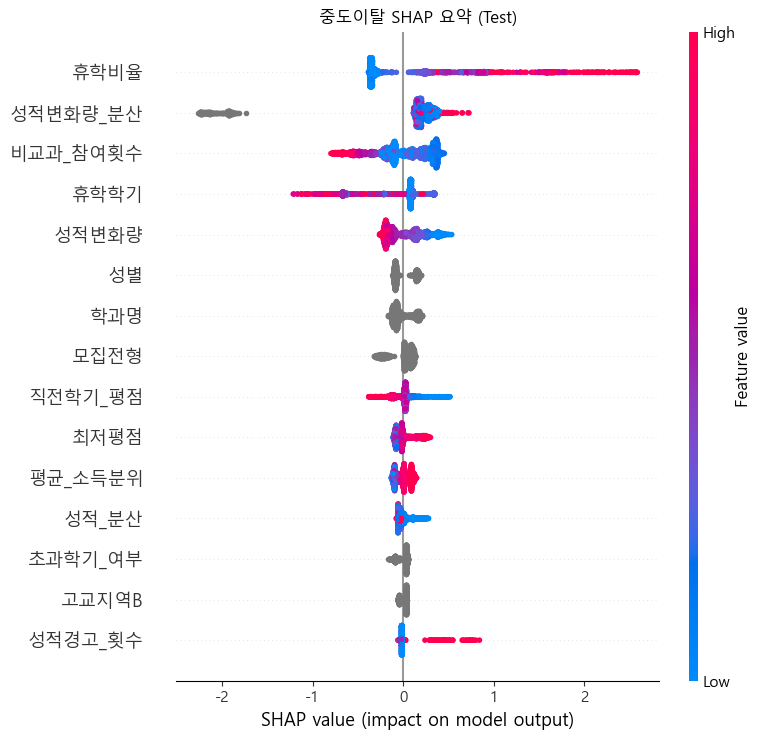

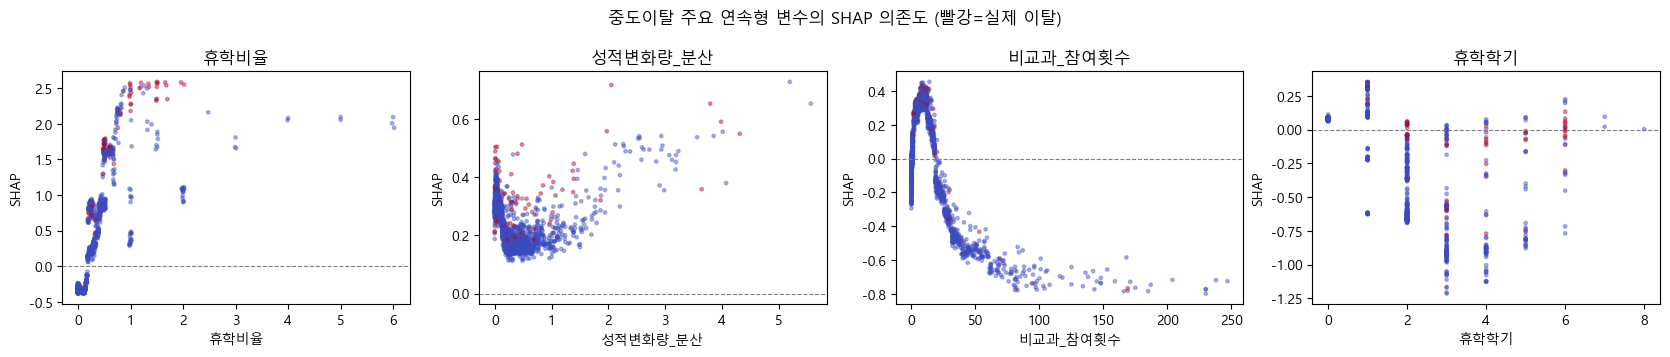


########## 중도이탈 ##########
[전역 중요도 Top 10]
 순위       변수  평균|SHAP|  비중(%)  누적비중(%)
  1     휴학비율     0.514 20.376   20.376
  2 성적변화량_분산     0.428 16.978   37.354
  3 비교과_참여횟수     0.257 10.202   47.555
  4     휴학학기     0.229  9.095   56.650
  5    성적변화량     0.175  6.954   63.604
  6       성별     0.113  4.485   68.089
  7      학과명     0.098  3.881   71.970
  8     모집전형     0.093  3.699   75.668
  9  직전학기_평점     0.077  3.053   78.722
 10     최저평점     0.074  2.945   81.666

[변수 방향성 Top 10]
 순위       변수  유형  Spearman(값↔SHAP)                                                     해석
  1     휴학비율 연속형              0.74     값이 클수록 위험↑ | 상위25%(≥0.25) +0.952, 하위25%(≤0) -0.343
  2 성적변화량_분산 연속형             -0.55  값이 클수록 위험↓ | 상위25%(≥0.41) +0.221, 하위25%(≤0.09) +0.325
  3 비교과_참여횟수 연속형             -0.26       값이 클수록 위험↓ | 상위25%(≥19) -0.398, 하위25%(≤0) -0.113
  4     휴학학기 연속형             -0.44        값이 클수록 위험↓ | 상위25%(≥2) -0.545, 하위25%(≤0) +0.081
  5    성적변화량 연속형             -0.97 값이 클수록 위험↓ | 상위25%(≥0.60)

In [14]:
from scipy.stats import spearmanr

def _fmt(v):
    try:
        f = float(v)
        return f"{f:.2f}" if not float(f).is_integer() else f"{int(f)}"
    except (TypeError, ValueError):
        return str(v)

def shap_analysis(model, X, y, prob, cat, name, extra_cols=None, top_n=15):
    sv_all = model.get_feature_importance(Pool(X, cat_features=cat), type="ShapValues")
    sv = pd.DataFrame(sv_all[:, :-1], columns=X.columns, index=X.index)
    base = float(sv_all[0, -1])

    # 1) 전역 중요도: 평균 |SHAP|
    imp = sv.abs().mean().sort_values(ascending=False)
    imp_df = pd.DataFrame({"순위": range(1, len(imp) + 1), "변수": imp.index,
                           "평균|SHAP|": imp.values, "비중(%)": imp.values / imp.sum() * 100})
    imp_df["누적비중(%)"] = imp_df["비중(%)"].cumsum()

    # 2) 방향성: 변수 값에 따라 SHAP이 어떻게 움직이는가
    rows = []
    for f in imp.index:
        x, s = X[f], sv[f]
        if f in cat:
            g = pd.DataFrame({"v": x.astype(str), "s": s}).groupby("v")["s"].agg(["mean", "count"])
            gg = g[g["count"] >= 20] if (g["count"] >= 20).sum() >= 2 else g
            up, dn = gg["mean"].idxmax(), gg["mean"].idxmin()
            rows.append({"변수": f, "유형": "범주형", "Spearman(값↔SHAP)": np.nan,
                         "높은값/해당 평균SHAP": gg.loc[up, "mean"], "낮은값/해당 평균SHAP": gg.loc[dn, "mean"],
                         "해석": f"'{up}'이면 위험↑({gg.loc[up,'mean']:+.3f}, n={int(gg.loc[up,'count'])}), "
                                 f"'{dn}'이면 위험↓({gg.loc[dn,'mean']:+.3f}, n={int(gg.loc[dn,'count'])})"})
            continue
        xn = pd.to_numeric(x, errors="coerce"); m = xn.notna()
        if xn[m].nunique() < 2:
            continue
        rho = spearmanr(xn[m], s[m]).correlation
        if xn[m].nunique() == 2:                       # 이진 변수: 1 vs 0 비교
            hi_v, lo_v = xn[m].max(), xn[m].min()
            hi, lo = s[m & (xn == hi_v)].mean(), s[m & (xn == lo_v)].mean()
            label = f"{_fmt(hi_v)}이면 {hi:+.3f}, {_fmt(lo_v)}이면 {lo:+.3f}"
        else:                                          # 연속형: 상위 25% vs 하위 25%
            q1, q3 = xn[m].quantile([.25, .75])
            hi, lo = s[m & (xn >= q3)].mean(), s[m & (xn <= q1)].mean()
            label = f"상위25%(≥{_fmt(q3)}) {hi:+.3f}, 하위25%(≤{_fmt(q1)}) {lo:+.3f}"
        trend = "값이 클수록 위험↑" if rho > 0.2 else ("값이 클수록 위험↓" if rho < -0.2 else "방향 약함/비선형")
        rows.append({"변수": f, "유형": "이진" if xn[m].nunique() == 2 else "연속형", "Spearman(값↔SHAP)": rho,
                     "높은값/해당 평균SHAP": hi, "낮은값/해당 평균SHAP": lo, "해석": f"{trend} | {label}"})
    dir_df = pd.DataFrame(rows)
    dir_df = imp_df[["순위", "변수", "평균|SHAP|"]].merge(dir_df, on="변수")

    # 3) 학생별 SHAP 값 + 주요 요인
    def factors(i, sign, k=3):
        r = sv.loc[i] * sign
        top = r[r > 0].nlargest(k)
        return "; ".join(f"{f}={_fmt(X.at[i, f])} ({sv.at[i, f]:+.2f})" for f in top.index)
    ind = pd.DataFrame(index=X.index)
    ind["ID"] = test_raw.loc[X.index, "ID"].values
    ind["실제"] = np.asarray(y)
    ind["예측확률"] = prob
    if extra_cols:
        for k, v in extra_cols.items():
            ind[k] = v
    ind["기준값(base)"] = base
    ind["SHAP합계"] = sv.sum(axis=1)
    ind["위험 증가 요인 Top3"] = [factors(i, 1) for i in X.index]
    ind["위험 감소 요인 Top3"] = [factors(i, -1) for i in X.index]
    ind = ind.sort_values("예측확률", ascending=False)
    sv_out = pd.concat([ind[["ID", "실제", "예측확률"]], sv.loc[ind.index].add_prefix("SHAP_")], axis=1)

    # 4) 그림: 요약(beeswarm) + 상위 연속형 변수 의존도
    shap.summary_plot(sv.values, X, show=False, max_display=top_n)
    plt.title(f"{name} SHAP 요약 (Test)"); plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/shap_{name}_summary.png", dpi=200, bbox_inches="tight"); plt.show()

    num_top = [f for f in imp.index if f not in cat and pd.to_numeric(X[f], errors="coerce").nunique() > 2][:4]
    fig, axes = plt.subplots(1, len(num_top), figsize=(4.2 * len(num_top), 3.6))
    for ax, f in zip(np.atleast_1d(axes), num_top):
        xn = pd.to_numeric(X[f], errors="coerce")
        ax.scatter(xn, sv[f], s=6, alpha=0.4, c=np.asarray(y), cmap="coolwarm")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_xlabel(f); ax.set_ylabel("SHAP"); ax.set_title(f)
    fig.suptitle(f"{name} 주요 연속형 변수의 SHAP 의존도 (빨강=실제 이탈)"); fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/shap_{name}_dependence.png", dpi=200, bbox_inches="tight"); plt.show()

    print(f"\n########## {name} ##########")
    print("[전역 중요도 Top 10]")
    print(imp_df.head(10).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print("\n[변수 방향성 Top 10]")
    print(dir_df.head(10)[["순위", "변수", "유형", "Spearman(값↔SHAP)", "해석"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))
    tp = ind[ind["실제"] == 1].head(3)
    print("\n[예시: 예측확률 상위 실제 이탈자 3명]")
    for _, r in tp.iterrows():
        print(f"- ID {r['ID']} (확률 {r['예측확률']:.3f}) ↑ {r['위험 증가 요인 Top3']} | ↓ {r['위험 감소 요인 Top3']}")
    return {"imp": imp_df, "dir": dir_df, "ind": ind, "sv": sv_out}

shap_early = shap_analysis(early["model"], X_te_early, y_te_early, p_te_early, EARLY_CAT, "조기이탈",
                           extra_cols={"예측": (p_te_early >= EARLY_THR).astype(int)})
shap_mid = shap_analysis(mid["model"], X_te_mid, y_te_mid, p_te_mid, MID_CAT, "중도이탈",
                         extra_cols={"위험군": assign_mid_risk(p_te_mid)})

with pd.ExcelWriter(f"{OUT_DIR}/SHAP_분석결과.xlsx") as w:
    for key, res in [("조기", shap_early), ("중도", shap_mid)]:
        res["imp"].to_excel(w, sheet_name=f"{key}_중요도", index=False)
        res["dir"].to_excel(w, sheet_name=f"{key}_방향성", index=False)
        res["ind"].to_excel(w, sheet_name=f"{key}_학생별요인", index=False)
        res["sv"].to_excel(w, sheet_name=f"{key}_학생별SHAP", index=False)
print("\n저장 완료: SHAP_분석결과.xlsx, shap_조기이탈_*.png, shap_중도이탈_*.png")

## 8. 학생 ID별 판정 사유 (Test 데이터)
각 학생이 **왜 조기이탈 예측 / 중도이탈 위험군으로 분류됐는지**를 학생 단위로 풀어서 보여줍니다.
- **판정 기준**: 조기이탈 확률 ≥ `EARLY_THR` → 조기이탈 예측 / 중도이탈 확률 ≥ `MID_LOW_THR` → 위험군 (그 외 저위험군)
- **사유 표기**: `변수=학생값 (전체 기준값) : 확률 A→B (+SHAP)`
  - 전체 기준값: 연속형은 Test 중앙값, 범주형은 최빈값
  - `확률 A→B`: 이 요인이 없었다면(SHAP 제거) 확률 A, 실제 예측확률 B → 이 요인이 확률을 얼마나 끌어올렸는지
- **판정결과**: 정탐(실제 이탈을 맞힘) / 오탐(이탈 아닌데 위험 판정) / 미탐(이탈인데 놓침) / 정상
- 결과 파일: `ID별_판정사유.xlsx`, 예시 학생 그림 `shap_ID_*.png`
- 특정 학생 조회: `explain_id(학생ID)`


[조기이탈] 판정결과 분포: {'정상': 2256, '정탐': 262, '오탐': 89, '미탐': 66}

[중도이탈] 판정결과 분포: {'정상': 1801, '오탐': 419, '정탐': 102, '미탐': 23}


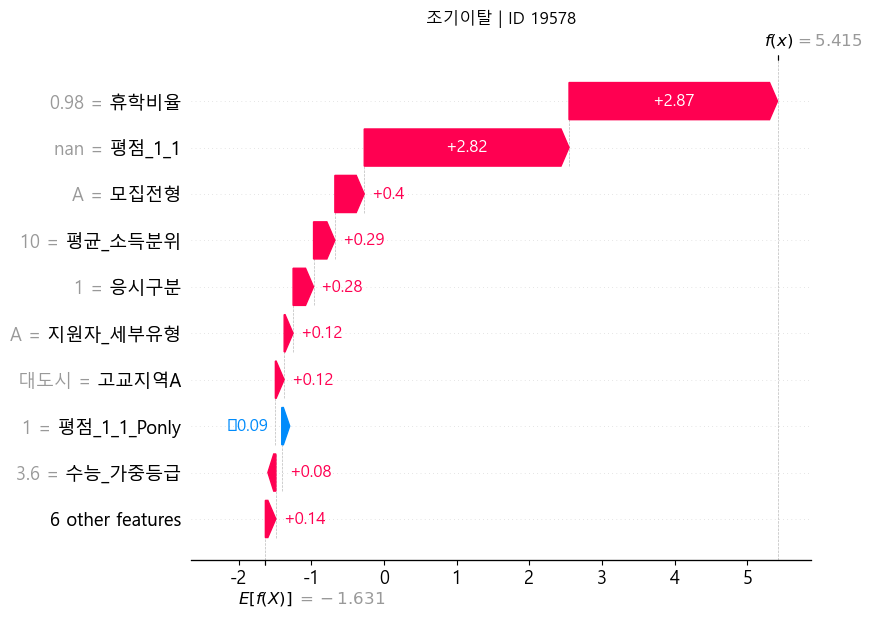

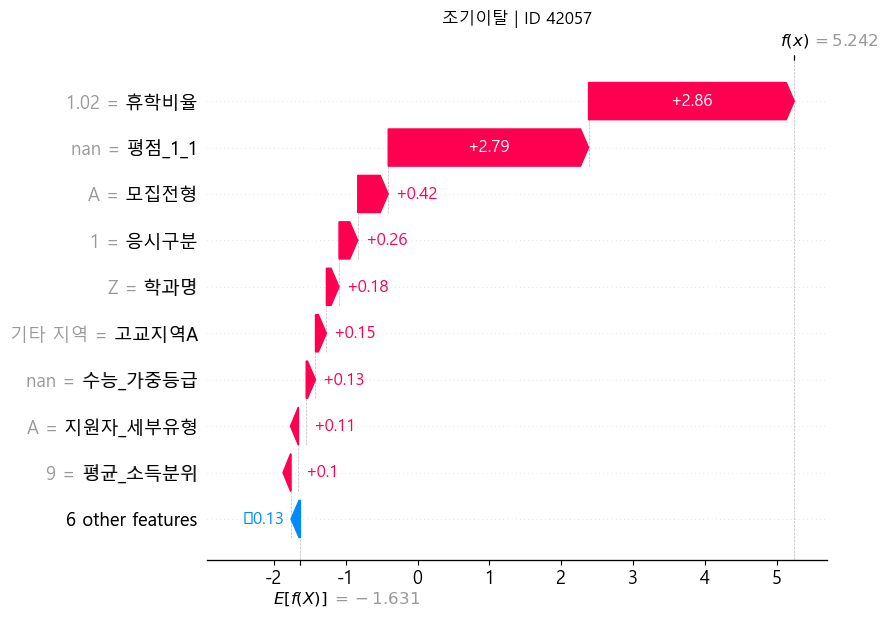

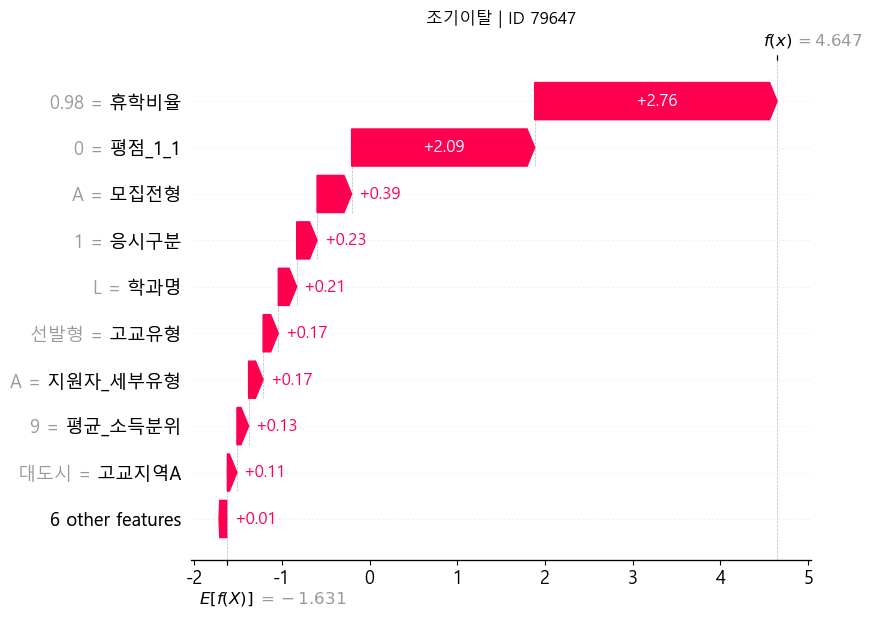

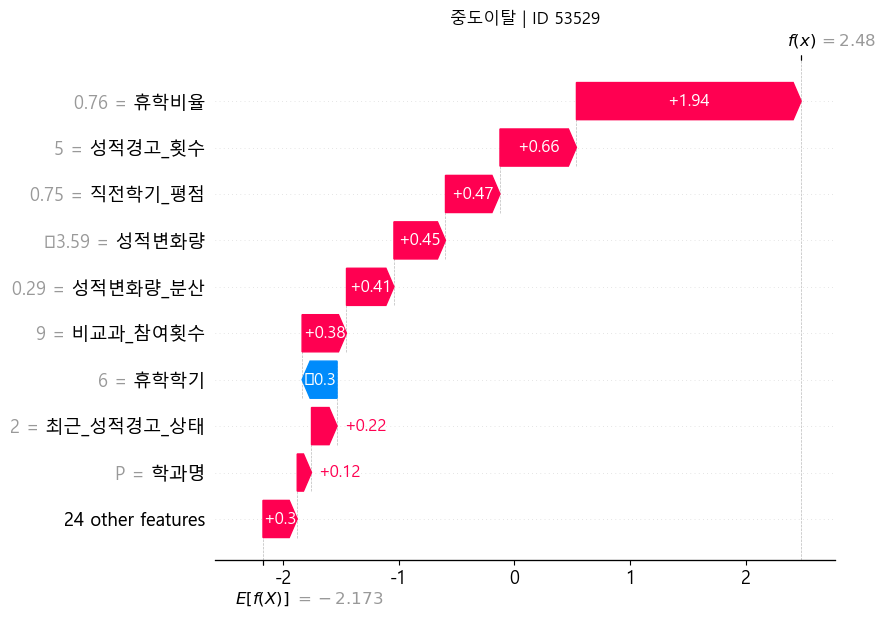

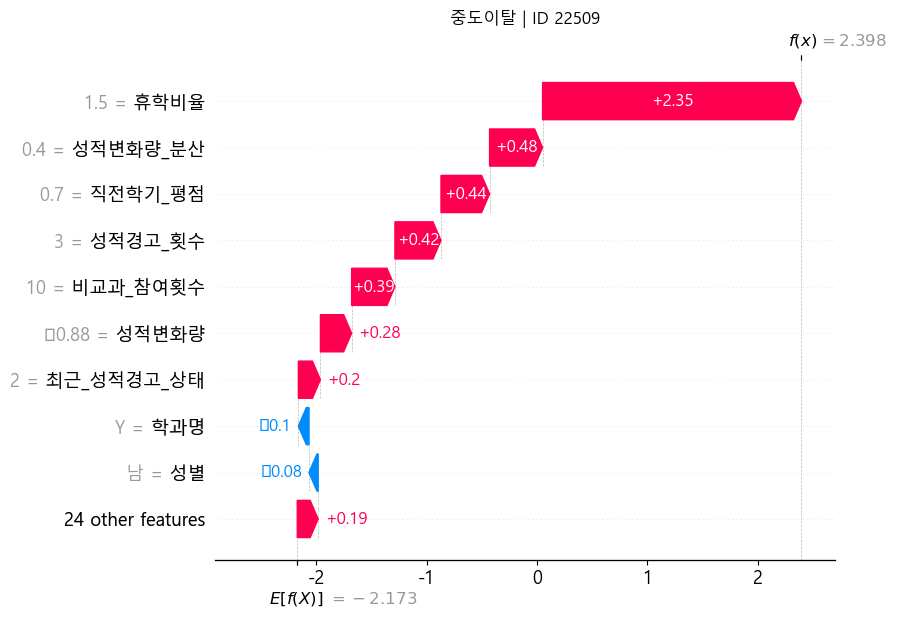

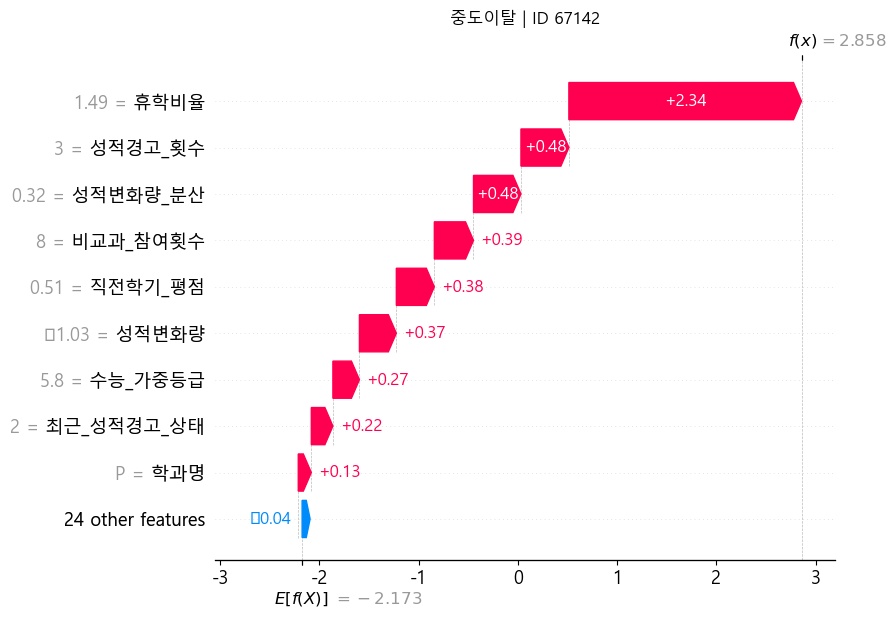


예시 학생 설명
[조기이탈] ID 19578 | 확률 0.996 | 판정: 조기이탈 예측 | 실제: 이탈 (정탐)
   조기이탈 확률 99.6%(기준 73.0% 이상)로 '조기이탈 예측' 판정. 주된 이유: 휴학비율 0.98 (전체 중앙값 0.03보다 높음), 평점_1_1 기록 없음, 모집전형가 'A'. 반면 평점_1_1_Ponly 1 (전체 중앙값 0보다 높음), 일반휴학_여부가 '1'은(는) 위험을 낮추는 쪽으로 작용.
   - 위험↑ 사유1: 휴학비율=0.98 (0.03) : 확률 0.93→1.00 (+2.87)
   - 위험↑ 사유2: 평점_1_1=값없음 (3.21) : 확률 0.93→1.00 (+2.82)
   - 위험↑ 사유3: 모집전형=A (A) : 확률 0.99→1.00 (+0.40)
   - 위험↑ 사유4: 평균_소득분위=10 (9) : 확률 0.99→1.00 (+0.29)
   - 위험↑ 사유5: 응시구분=1 (1) : 확률 0.99→1.00 (+0.28)
   - 위험↓ 요인1: 평점_1_1_Ponly=1 (0) : 확률 1.00→1.00 (-0.09)
   - 위험↓ 요인2: 일반휴학_여부=1 (0) : 확률 1.00→1.00 (-0.07)
[중도이탈] ID 19578: 평가 대상 아님 (조기제적자는 중도이탈 모델에서 제외)

[조기이탈] ID 42057 | 확률 0.995 | 판정: 조기이탈 예측 | 실제: 이탈 (정탐)
   조기이탈 확률 99.5%(기준 73.0% 이상)로 '조기이탈 예측' 판정. 주된 이유: 휴학비율 1.02 (전체 중앙값 0.03보다 높음), 평점_1_1 기록 없음, 모집전형가 'A'. 반면 평점_1_1_Ponly 1 (전체 중앙값 0보다 높음), 일반휴학_여부가 '1'은(는) 위험을 낮추는 쪽으로 작용.
   - 위험↑ 사유1: 휴학비율=1.02 (0.03) : 확률 0.92→0.99 (+2.86)
   - 위험↑ 사유2: 평점_1_1=값없음 (3.21) : 확률 0.92→0.99 (+2.79)
   - 위험↑

In [15]:
def _sig(z):
    return 1 / (1 + np.exp(-z))

def _val(v):
    if v is None or (isinstance(v, float) and np.isnan(v)) or (isinstance(v, str) and v.lower() == "nan"):
        return "값없음"
    try:
        f = float(v); return f"{f:.2f}" if not f.is_integer() else f"{int(f)}"
    except (TypeError, ValueError):
        return str(v)

def _phrase(f, v, ref, is_cat):
    """학생 값을 사람이 읽기 쉬운 문장 조각으로"""
    sv_, rv_ = _val(v), _val(ref)
    if sv_ == "값없음":
        return f"{f} 기록 없음"
    if is_cat:
        return f"{f}가 '{sv_}'"
    try:
        d = float(v) - float(ref)
        comp = "높음" if d > 0 else ("낮음" if d < 0 else "같음")
        return f"{f} {sv_} (전체 중앙값 {rv_}보다 {comp})"
    except (TypeError, ValueError):
        return f"{f} {sv_}"

def explain_by_id(model, X, y, prob, thr, cat, model_name, pos_label, neg_label, n_up=5, n_down=3):
    sv_all = model.get_feature_importance(Pool(X, cat_features=cat), type="ShapValues")
    sv = pd.DataFrame(sv_all[:, :-1], columns=X.columns, index=X.index)
    base = float(sv_all[0, -1]); logit = sv.sum(axis=1) + base
    ref = {f: (X[f].astype(str).mode().iloc[0] if f in cat else pd.to_numeric(X[f], errors="coerce").median())
           for f in X.columns}
    ids = test_raw.loc[X.index, "ID"].values
    yy = np.asarray(y); prob = np.asarray(prob)
    wide, long = [], []
    for k, i in enumerate(X.index):
        flagged = prob[k] >= thr; actual = int(yy[k])
        outcome = ("정탐" if actual else "오탐") if flagged else ("미탐" if actual else "정상")
        s = sv.loc[i]
        ups = s[s > 0].sort_values(ascending=False).head(n_up)
        downs = s[s < 0].sort_values().head(n_down)
        row = {"ID": ids[k], "모델": model_name, "예측확률": prob[k], "판정기준(임계값)": thr,
               "판정": pos_label if flagged else neg_label, "실제": "이탈" if actual else "비이탈", "판정결과": outcome}
        for r, (f, v) in enumerate(ups.items(), 1):
            p_wo = _sig(logit[i] - v)
            row[f"위험↑ 사유{r}"] = f"{f}={_val(X.at[i, f])} ({_val(ref[f])}) : 확률 {p_wo:.2f}→{prob[k]:.2f} (+{v:.2f})"
            long.append({"ID": ids[k], "모델": model_name, "판정": row["판정"], "구분": "위험↑", "순위": r, "변수": f,
                         "학생값": _val(X.at[i, f]), "전체기준값": _val(ref[f]), "SHAP": v,
                         "요인 제외시 확률": p_wo, "예측확률": prob[k]})
        for r, (f, v) in enumerate(downs.items(), 1):
            p_wo = _sig(logit[i] - v)
            row[f"위험↓ 요인{r}"] = f"{f}={_val(X.at[i, f])} ({_val(ref[f])}) : 확률 {p_wo:.2f}→{prob[k]:.2f} ({v:.2f})"
            long.append({"ID": ids[k], "모델": model_name, "판정": row["판정"], "구분": "위험↓", "순위": r, "변수": f,
                         "학생값": _val(X.at[i, f]), "전체기준값": _val(ref[f]), "SHAP": v,
                         "요인 제외시 확률": p_wo, "예측확률": prob[k]})
        top = [_phrase(f, X.at[i, f], ref[f], f in cat) for f in ups.index[:3]]
        protect = [_phrase(f, X.at[i, f], ref[f], f in cat) for f in downs.index[:2]]
        if flagged:
            sent = (f"{model_name} 확률 {prob[k]:.1%}(기준 {thr:.1%} 이상)로 '{pos_label}' 판정. "
                    f"주된 이유: {', '.join(top) if top else '-'}.")
            if protect:
                sent += f" 반면 {', '.join(protect)}은(는) 위험을 낮추는 쪽으로 작용."
        else:
            sent = (f"{model_name} 확률 {prob[k]:.1%}(기준 {thr:.1%} 미만)로 '{neg_label}'. "
                    f"위험을 낮춘 요인: {', '.join(protect) if protect else '-'}.")
            if top:
                sent += f" 다만 {', '.join(top[:2])}은(는) 위험을 높이는 쪽."
        row["설명"] = sent
        wide.append(row)
    wide = pd.DataFrame(wide).sort_values("예측확률", ascending=False).reset_index(drop=True)
    long = pd.DataFrame(long)
    exp = shap.Explanation(values=sv.values, base_values=np.full(len(sv), base),
                           data=X.astype(object).values, feature_names=list(X.columns))
    return wide, long, exp, list(X.index)

id_early, long_early, exp_early, idx_early = explain_by_id(
    early["model"], X_te_early, y_te_early, p_te_early, EARLY_THR, EARLY_CAT, "조기이탈", "조기이탈 예측", "비대상")
id_mid, long_mid, exp_mid, idx_mid = explain_by_id(
    mid["model"], X_te_mid, y_te_mid, p_te_mid, MID_LOW_THR, MID_CAT, "중도이탈", "위험군", "저위험군")

def explain_id(student_id):
    """학생 ID 하나에 대해 두 모델의 판정 사유를 출력"""
    for name, w in [("조기이탈", id_early), ("중도이탈", id_mid)]:
        r = w[w["ID"] == student_id]
        if r.empty:
            print(f"[{name}] ID {student_id}: 평가 대상 아님" + (" (조기제적자는 중도이탈 모델에서 제외)" if name == "중도이탈" else ""))
            continue
        r = r.iloc[0]
        print(f"[{name}] ID {student_id} | 확률 {r['예측확률']:.3f} | 판정: {r['판정']} | 실제: {r['실제']} ({r['판정결과']})")
        print("   " + r["설명"])
        for c in [c for c in w.columns if c.startswith("위험↑") or c.startswith("위험↓")]:
            if isinstance(r[c], str):
                print(f"   - {c}: {r[c]}")

def plot_id(exp, idx_list, X, student_id, model_name):
    pos = int(np.where(test_raw.loc[idx_list, "ID"].values == student_id)[0][0])
    plt.figure()
    shap.plots.waterfall(exp[pos], max_display=10, show=False)
    plt.title(f"{model_name} | ID {student_id}")
    plt.savefig(f"{FIG_DIR}/shap_ID_{model_name}_{student_id}.png", dpi=180, bbox_inches="tight"); plt.show()

# 판정 결과 요약
for name, w in [("조기이탈", id_early), ("중도이탈", id_mid)]:
    print(f"\n[{name}] 판정결과 분포:", w["판정결과"].value_counts().to_dict())

# 예시: 각 모델에서 정탐 상위 2명 + 오탐 상위 1명
examples = {}
for name, w, exp, idxs, X in [("조기이탈", id_early, exp_early, idx_early, X_te_early),
                              ("중도이탈", id_mid, exp_mid, idx_mid, X_te_mid)]:
    ex = list(w[w["판정결과"] == "정탐"]["ID"].head(2)) + list(w[w["판정결과"] == "오탐"]["ID"].head(1))
    examples[name] = ex
    for sid in ex:
        plot_id(exp, idxs, X, sid, name)
print("\n예시 학생 설명")
for name, ex in examples.items():
    for sid in ex:
        explain_id(sid); print()

with pd.ExcelWriter(f"{OUT_DIR}/ID별_판정사유.xlsx") as wr:
    id_early[id_early["판정"] == "조기이탈 예측"].to_excel(wr, sheet_name="조기이탈_예측자", index=False)
    id_mid[id_mid["판정"] == "위험군"].to_excel(wr, sheet_name="중도이탈_위험군", index=False)
    id_early.to_excel(wr, sheet_name="조기이탈_전체", index=False)
    id_mid.to_excel(wr, sheet_name="중도이탈_전체", index=False)
    pd.concat([long_early, long_mid]).to_excel(wr, sheet_name="요인상세(long)", index=False)
print("저장 완료: ID별_판정사유.xlsx, shap_ID_*.png")